In [55]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
d = {"Experience":[2,5,3,7,1,6,4,8],"Gender":[0,0,0,0,1,1,1,1] ,"Hired":[1,1,1,1,0,0,0,0]}
df = pd.DataFrame(data=d)

In [6]:
df

,Experience,Gender,Hired
0,2,0,1
1,5,0,1
2,3,0,1
3,7,0,1
4,1,1,0
5,6,1,0
6,4,1,0
7,8,1,0


In [8]:
x = df.drop("Hired",axis=1)

In [10]:
y = df['Hired']

In [12]:
x

,Experience,Gender
0,2,0
1,5,0
2,3,0
3,7,0
4,1,1
5,6,1
6,4,1
7,8,1


In [14]:
y

0    1
1    1
2    1
3    1
4    0
5    0
6    0
7    0
Name: Hired, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8)

In [45]:
y_train

6    0
2    1
5    0
0    1
3    1
4    0
Name: Hired, dtype: int64

In [30]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [32]:
model

LogisticRegression()

In [34]:
model.fit(x_train,y_train)

LogisticRegression()

In [37]:
y_pred = model.predict(x_test)

In [39]:
y_pred

array([0, 1])

In [47]:
from sklearn.metrics import classification_report
cr = classification_report(y_pred,y_test)

In [49]:
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [51]:
def predict_hiring(model):
        experience = float(input("Enter years of experience: "))
        gender = int(input("Enter gender (0 = Female, 1 = Male): "))
        new_data = np.array([[experience, gender]])
        prediction = model.predict(new_data)[0]

        if prediction == 1:
            print("Hired")
        else:
            print("NOT  Hired ")

In [57]:
predict_hiring(model)

Enter years of experience:  25
Enter gender (0 = Male, 1 = Female):  1


Hired


/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [139]:
df = pd.read_csv("/home/admin1/Dataset.csv")

In [141]:
df

,gender,age,education_level,experience_years,screening_score,shortlisted
0,Male,35,Masters,1,72.473130,0
1,Female,32,Bachelors,15,55.004084,0
2,Male,36,Masters,19,60.156004,0
3,Male,44,Bachelors,6,75.846397,0
4,Male,39,High School,1,43.297540,1
...,...,...,...,...,...,...
1995,Male,29,Masters,15,67.250957,0
1996,Female,24,Bachelors,14,73.093133,1
1997,Male,25,Bachelors,1,71.634872,0
1998,Male,41,High School,8,65.387954,0


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            2000 non-null   object 
 1   age               2000 non-null   int64  
 2   education_level   2000 non-null   object 
 3   experience_years  2000 non-null   int64  
 4   screening_score   2000 non-null   float64
 5   shortlisted       2000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 93.9+ KB


In [145]:
df.isnull().sum()

gender              0
age                 0
education_level     0
experience_years    0
screening_score     0
shortlisted         0
dtype: int64

In [147]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_edu = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['education_level'] = le_edu.fit_transform(df['education_level'])

In [149]:
df

,gender,age,education_level,experience_years,screening_score,shortlisted
0,1,35,2,1,72.473130,0
1,0,32,0,15,55.004084,0
2,1,36,2,19,60.156004,0
3,1,44,0,6,75.846397,0
4,1,39,1,1,43.297540,1
...,...,...,...,...,...,...
1995,1,29,2,15,67.250957,0
1996,0,24,0,14,73.093133,1
1997,1,25,0,1,71.634872,0
1998,1,41,1,8,65.387954,0


In [151]:
y.value_counts()

shortlisted
0    1195
1     805
Name: count, dtype: int64

In [153]:
df['gender'].value_counts()

gender
1    1016
0     984
Name: count, dtype: int64

In [253]:
selection_rate = df.groupby('gender')['shortlisted'].mean()
print(selection_rate)

gender
0    0.420732
1    0.384843
Name: shortlisted, dtype: float64


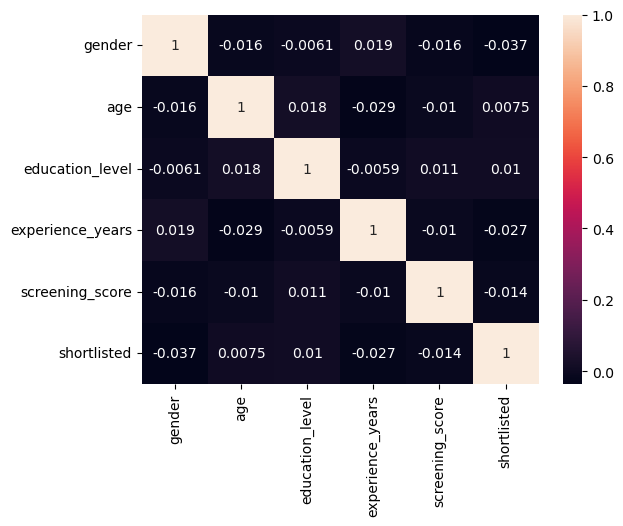

In [257]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

In [255]:
def bias_report(df, protected_feature, target):
    report = df.groupby(protected_feature)[target].mean()
    print(report)
    
    diff = report.max() - report.min()
    print("Bias Difference:", diff)

bias_report(df, 'gender', 'shortlisted')
bias_report(df, 'education_level', 'shortlisted')

gender
0    0.420732
1    0.384843
Name: shortlisted, dtype: float64
Bias Difference: 0.0358891876320338
education_level
0    0.401768
1    0.396419
2    0.396728
3    0.460784
Name: shortlisted, dtype: float64
Bias Difference: 0.06436487638533672


In [155]:
x = df.drop("shortlisted",axis=1)
y = df['shortlisted']

In [157]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8)

In [201]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [203]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [205]:
model.fit(x_train,y_train)

LogisticRegression()

In [207]:
y_pred = model.predict(x_test)

In [209]:
from sklearn.metrics import classification_report,accuracy_score
cr = classification_report(y_test,y_pred)
acc = accuracy_score(y_test,y_pred)

/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [211]:
print(cr)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       245
           1       0.00      0.00      0.00       155

    accuracy                           0.61       400
   macro avg       0.31      0.50      0.38       400
weighted avg       0.38      0.61      0.47       400



In [213]:
acc

0.6125

In [215]:
from sklearn.svm import SVC
svm = SVC()

In [217]:
svm.fit(x_train,y_train)

SVC()

In [219]:
y_pred1 = svm.predict(x_test)

In [221]:
from sklearn.metrics import classification_report,accuracy_score
cr = classification_report(y_test,y_pred1)
acc1 = accuracy_score(y_test,y_pred1)

In [223]:
print(cr)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       245
           1       0.50      0.01      0.01       155

    accuracy                           0.61       400
   macro avg       0.56      0.50      0.39       400
weighted avg       0.57      0.61      0.47       400



In [225]:
print(acc1)

0.6125


In [239]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [241]:
nb.fit(x_train,y_train)

GaussianNB()

In [243]:
y_pred2 = nb.predict(x_test)

In [245]:
from sklearn.metrics import classification_report,accuracy_score
cr = classification_report(y_test,y_pred2)
acc2 = accuracy_score(y_test,y_pred2)

/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [247]:
print(cr)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       245
           1       0.00      0.00      0.00       155

    accuracy                           0.61       400
   macro avg       0.31      0.50      0.38       400
weighted avg       0.38      0.61      0.47       400



In [249]:
print(acc2)

0.6125


In [262]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

In [264]:
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [269]:
y_pred3 = dt.predict(x_test)

In [277]:
from sklearn.metrics import classification_report,accuracy_score
cr = classification_report(y_test,y_pred3)
acc3 = accuracy_score(y_test,y_pred3)
print(cr)
print("Accuracy:",acc3)

              precision    recall  f1-score   support

           0       0.61      0.55      0.58       245
           1       0.38      0.45      0.41       155

    accuracy                           0.51       400
   macro avg       0.50      0.50      0.49       400
weighted avg       0.52      0.51      0.51       400

Accuracy: 0.5075


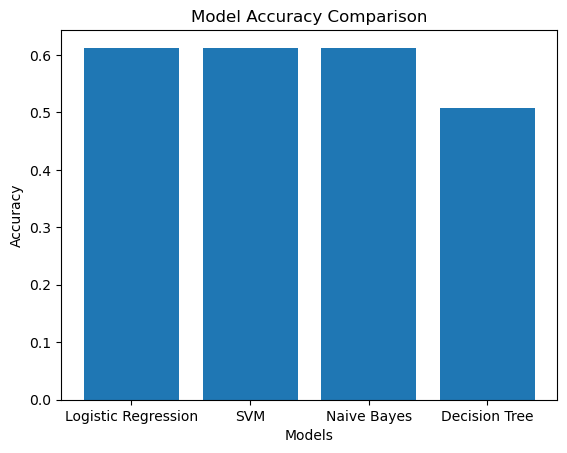

In [279]:
import matplotlib.pyplot as plt
models = ['Logistic Regression', 'SVM', 'Naive Bayes',"Decision Tree"]
accuracies = [acc,acc1,acc2,acc3]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()